<h1>AirBnB Price Analysis and Prediction </h1>

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import metrics

**Importing Dataset**

In [2]:
df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**Information on Columns:**

1.  id -> Airbnb Listing Id
2.  name -> Airbnb Listing Name
3.  host_id -> Host Name who is hosting the Airbnb Listing
4.  neighbourhood_group -> Name of Borough in New York
5.  neighbourhood -> Name of Neighbourhood in New York
6.  latitude -> Latitude of Airbnb Listing
7.  longitude -> Longitude of Airbnb Listing
8.  room_type -> Type of Room 
9.  price -> Price of that particular Airbnb Listing
10. minimum_nights -> Minimum number of nights to stay for that particular Airbnb Listing
11. number_of_reviews -> Number of Reviews of that particular Airbnb Listing
12. last_review -> Date of the last review of that particular listing (Note:- We will assume that the last review was written during or after their stay as this data is not having any other date & time column.)
13. reviews_per_month -> Average Reviews each month
14. calculated_host_listings_count -> Number of times Host have hosted a listing
15. availability_365 -> Number of days listing stays available each year.

**Checking Datatypes of attributes of dataset**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
id                                48895 non-null int64
name                              48879 non-null object
host_id                           48895 non-null int64
host_name                         48874 non-null object
neighbourhood_group               48895 non-null object
neighbourhood                     48895 non-null object
latitude                          48895 non-null float64
longitude                         48895 non-null float64
room_type                         48895 non-null object
price                             48895 non-null int64
minimum_nights                    48895 non-null int64
number_of_reviews                 48895 non-null int64
last_review                       38843 non-null object
reviews_per_month                 38843 non-null float64
calculated_host_listings_count    48895 non-null int64
availability_365                  48895 non-null int64

**Checking for null values**

In [4]:
df.isnull().mean() * 100

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

**Findings:**
* 'name' & 'host_name' columns are containing 0.03% & 0.04% null values which can be dropped easily.
* 'last_review' & 'reviews_per_month' columns are containing 20% null values. Theoretically, column containing 25%-30% null values can be dropped.
* Year, month name & day name can be extracted from 'last_review' column.

In [6]:
#last_review converted to datetime datatype

df['last_review'] = pd.to_datetime(df['last_review'])

In [7]:
#Year, month name & day name is extracted from 'last_review' column

df['Year_last_review'] =  df['last_review'].dt.year
df['Month_last_review'] = df['last_review'].dt.month_name()
df['Day_last_review'] = df['last_review'].dt.day_name()


#dropped 'last_review' column

df.drop(columns=['last_review'],axis=1,inplace=True)

In [8]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Year_last_review,Month_last_review,Day_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,October,Friday
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,May,Tuesday
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,NaN,NaN,NaN
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,2019.0,July,Friday
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,2018.0,November,Monday


In [9]:
#Exporting CSV for further analysis

df.to_csv('AirBnb_New_York_data.csv',index=True)

In [10]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
Year_last_review                  10052
Month_last_review                 10052
Day_last_review                   10052
dtype: int64

In [11]:
#Dropping null values

df = df.dropna()

In [12]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
Year_last_review                  0
Month_last_review                 0
Day_last_review                   0
dtype: int64

In [13]:
df.shape

(38821, 18)

# **Data Visualization and Analysis**

**Analysis of Year and Price:**

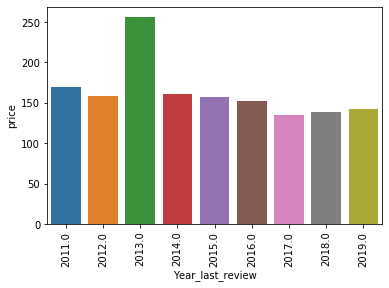

In [14]:
sns.barplot(x=df['Year_last_review'],y=df['price'], ci=None)
plt.xticks(rotation='vertical')
plt.show()

**Findings:**

* 2013 is having a sudden hike and then 2014 to 2019 is having almost same trend.

**Analysis of Month and Price:**

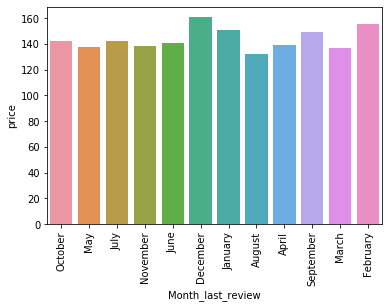

In [15]:
sns.barplot(x=df['Month_last_review'],y=df['price'], ci=None)
plt.xticks(rotation='vertical')
plt.show()

**Findings:**

* December, January & February having more Price hike whereas other months having almost same trend.
* This can be due to more tourists in winter season in New York.
* Tourists Hike is directly porpotional to Price Hike.

**Analysis of Day of the week and Price:**

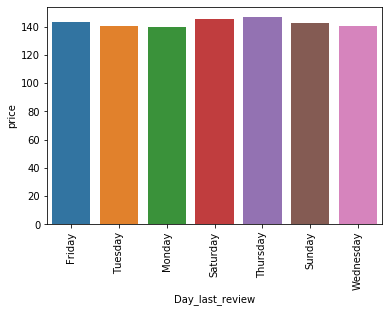

In [16]:
sns.barplot(x=df['Day_last_review'],y=df['price'], ci=None)
plt.xticks(rotation='vertical')
plt.show()

**Findings:**

* There is no such trend between Day and Price.

In [17]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Year_last_review,Month_last_review,Day_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,October,Friday
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,May,Tuesday
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,2019.0,July,Friday
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,2018.0,November,Monday
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129,2019.0,June,Saturday


**Analysis on 'neighbourhood_group' column**

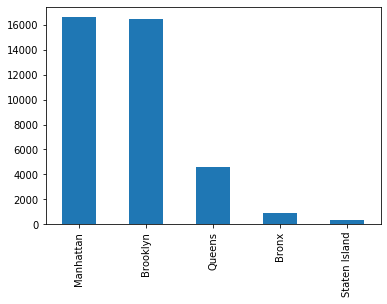

In [18]:
df['neighbourhood_group'].value_counts().plot(kind='bar')

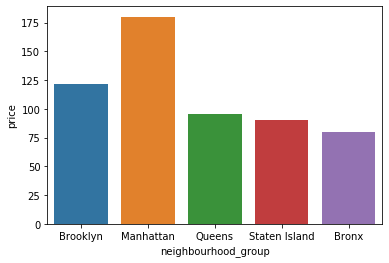

In [19]:
sns.barplot(x=df['neighbourhood_group'],y=df['price'], ci=None)

**Findings:**

* Manhattan & Brooklyn are most favourable area for Airbnb listings and also having prices more than others.
* Manhattan and Brooklyn have many of tourist attractions in New York like Empire State Building, Statue of Liberty, Brooklyn Bridge.
* Both Manhattan and Brooklyn have airports nearby which also make these place popular among tourists.

**Analysis on 'neighbourhood' column**

In [20]:
df['neighbourhood'].value_counts()

Williamsburg                  3163
Bedford-Stuyvesant            3141
Harlem                        2204
Bushwick                      1942
Hell's Kitchen                1528
East Village                  1489
Upper West Side               1482
Upper East Side               1405
Crown Heights                 1265
Midtown                        986
East Harlem                    943
Greenpoint                     866
Chelsea                        827
Lower East Side                738
Washington Heights             721
Astoria                        709
West Village                   610
Financial District             509
Flatbush                       496
Clinton Hill                   480
Prospect-Lefferts Gardens      449
East Flatbush                  426
Long Island City               416
Park Slope                     410
Fort Greene                    401
Flushing                       363
Kips Bay                       337
Chinatown                      321
Sunset Park         

**Findings:**

* Williamsburg and Bedford-Stuyvesant are the top 2 popular neighbourhoods among the tourists and other customers of AirBnB.

**Analysis in 'room_type' column**

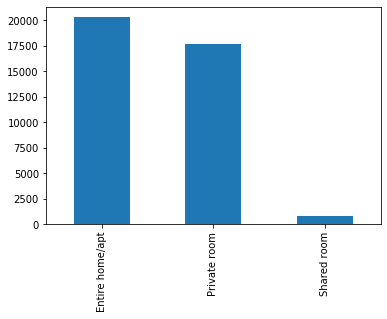

In [21]:
df['room_type'].value_counts().plot(kind='bar')

**Findings:**

* Entire Homes/Apartments are fairly favourable among Airbnb users.

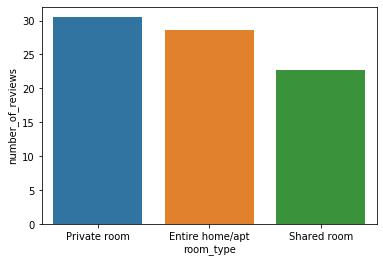

In [22]:
sns.barplot(x=df['room_type'],y=df['number_of_reviews'], ci=None)

**Findings:**

* Private Rooms & Entire Homes/Apartments are having more no. of reviews.

**Analysis on 'Price' column**

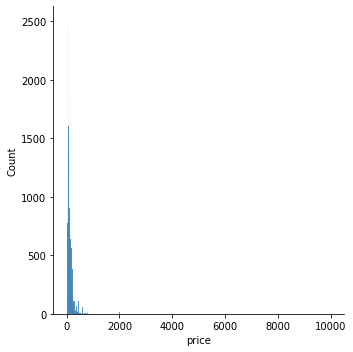

In [23]:
sns.displot(df['price'])

C:\Users\Pooja\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log
  """Entry point for launching an IPython kernel.


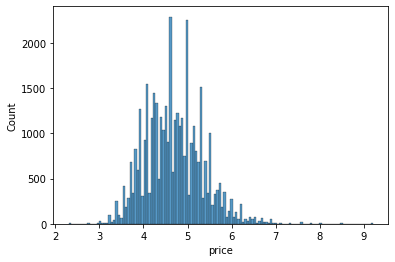

In [24]:
sns.histplot(np.log(df['price']))

Distribution Plot of 'price' column

In [25]:
print('Range of Price of AirBnb Flat:',round(np.exp(4.5),2),'-',round(np.exp(5.2),2))

Range of Price of AirBnb Flat: 90.02 - 181.27


In [26]:
round(df['price'].mean(),2)

142.33

In [27]:
df['price'].mode()[0]

150

**Findings:**

* Average Price of Airbnb is 152.74 US dollars and mode is 100 US dollars.
* 100 - 150 US Dollars price budget is favourable among Airbnb users.

**Analysis on 'minimum_nights' column**

In [28]:
df['minimum_nights'].mode()[0]

2

In [29]:
round(df['minimum_nights'].mean())

6

In [30]:
min_n_30 = df[df['minimum_nights'] > 30]
min_n_30['neighbourhood_group'].value_counts()

Manhattan        250
Brooklyn         148
Queens            32
Bronx              8
Staten Island      1
Name: neighbourhood_group, dtype: int64

In [31]:
min_n_365 = df[df['minimum_nights'] > 365]
min_n_365['neighbourhood_group'].value_counts()

Brooklyn     3
Manhattan    2
Queens       1
Name: neighbourhood_group, dtype: int64

**Findings:**

* Average Minimum Nights to stay is 7 days.
* Best Area to stay for more than 1 month is Manhattan.
* There are some Airbnb which are offering minimum nights to stay for 1 Year.

**Analysis on 'number_of_reviews' column**

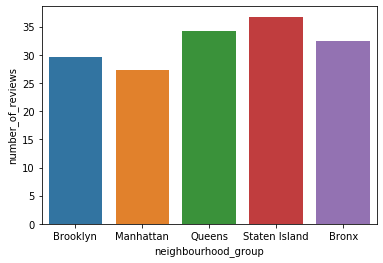

In [32]:
sns.barplot(x=df['neighbourhood_group'],y=df['number_of_reviews'], ci=None)

In [33]:
df[['neighbourhood_group','number_of_reviews']].groupby(df['neighbourhood_group']).mean()

,number_of_reviews
neighbourhood_group,
Bronx,32.381714
Brooklyn,29.574427
Manhattan,27.322423
Queens,34.318023
Staten Island,36.754777


**Findings:**

* Staten Island is having more No. of Reviews.
* Staten Island is the second wealthiest borough and the least populated borough in NYC, according to this [article](https://www.timeout.com/newyork/news/13-strange-things-you-probably-didnt-know-about-staten-island-081817#:~:text=Staten%20Island%20is%20the%20second%20wealthiest%20borough.).
* Rich People prefers to stay in Staten Island and maybe promoting Airbnb resulting in attracting tourists and more no. of reviews.

**Analysis on 'availability_365' column**

In [34]:
temp_avail = df[df['availability_365'] > 0]

C:\Users\Pooja\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


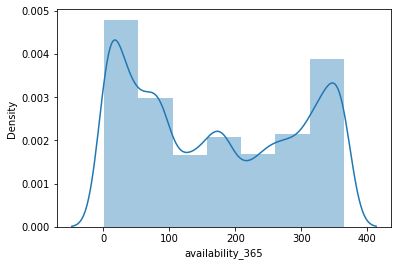

In [35]:
sns.distplot(temp_avail['availability_365'],bins=7)

**Findings:**

* Upto 50 days of availability of Airbnb is favourable among users.
* Upto 300 - 365 days of availability of Airbnb is also favourable among users.

In [36]:
#Dropping more columns 

df.drop(columns=['reviews_per_month','Year_last_review','Month_last_review','Day_last_review'],axis=1,inplace=True)
df.drop(columns=['id','name','host_id','host_name','latitude','longitude'],axis=1,inplace=True)


In [37]:
#Exporting final CSV
df.to_csv('Cleaned_AirBnb.csv',index=True)

In [38]:
df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,2,355
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,1,0
5,Manhattan,Murray Hill,Entire home/apt,200,3,74,1,129


# Prediction

In [39]:
y = df['price']
x= df.drop(['price'],axis=1)

In [40]:
from sklearn.model_selection import train_test_split
# split data into train and test sets in 80:20 ratio respectively
#Test: 0.2 Train: 0.8
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [41]:
# Importing LabelEncoder for categorical Variables
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputClassifier
le=LabelEncoder()

# Iterating over all the common columns in train and test
for col in x_test.columns.values:
       if x_test[col].dtypes=='object':              # Encoding only categorical variables
            df=x_train[col].append(x_test[col])     # Using whole data to form an exhaustive list of levels
            le.fit(df.values)
            x_train[col]=le.transform(x_train[col])
            x_test[col]=le.transform(x_test[col])

C:\Users\Pooja\Anaconda3\lib\site-packages\ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # This is added back by InteractiveShellApp.init_path()
C:\Users\Pooja\Anaconda3\lib\site-packages\ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  if sys.path[0] == '':


In [42]:
x_train.head()

,neighbourhood_group,neighbourhood,room_type,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
21790,3,4,0,1,73,1,273
8749,1,149,0,2,1,1,0
5507,2,64,0,30,11,39,319
21741,1,212,1,1,14,1,0
11574,2,61,0,1,48,3,326


In [43]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=350,random_state=42)
regressor.fit(x_train, y_train)
rf_pred = regressor.predict(x_test)

In [44]:
print("MAE" , metrics.mean_absolute_error(y_test, rf_pred))
print("MSE" , metrics.mean_squared_error(y_test, rf_pred))
print("RMSE" , np.sqrt(metrics.mean_squared_error(y_test, rf_pred)))
print("R2" , metrics.explained_variance_score(y_test, rf_pred))

MAE 58.91534111159455
MSE 34926.83202731119
RMSE 186.8872173994551
R2 -0.05325473010747017


In [45]:
from xgboost import XGBRegressor
xgbreg = XGBRegressor(n_estimators=10, random_state=42, n_jobs=2, max_depth=4, learning_rate=0.1)
xgbreg.fit(x_train, y_train)
y_pred_xg1 = xgbreg.predict(x_test)

In [46]:
print("MAE" , metrics.mean_absolute_error(y_test, y_pred_xg1))
print("MSE" , metrics.mean_squared_error(y_test, y_pred_xg1))
print("RMSE" , np.sqrt(metrics.mean_squared_error(y_test, y_pred_xg1)))
print("R2" , metrics.r2_score(y_test, y_pred_xg1))

MAE 60.00075238062655
MSE 31380.561612629484
RMSE 177.14559439237965
R2 0.052324605458681006


In [47]:
from sklearn.tree import DecisionTreeRegressor
DTree=DecisionTreeRegressor(min_samples_leaf=.0001)
DTree.fit(x_train,y_train)
dt_pred = DTree.predict(x_test)

In [48]:
print("MAE" , metrics.mean_absolute_error(y_test, dt_pred))
print("MSE" , metrics.mean_squared_error(y_test, dt_pred))
print("RMSE" , np.sqrt(metrics.mean_squared_error(y_test, dt_pred)))
print("R2" , metrics.explained_variance_score(y_test, dt_pred))

MAE 64.72187786043322
MSE 39987.505471574026
RMSE 199.96876123928465
R2 -0.20719569634341384
